In [1]:
import os, json, random, time, shutil, warnings
from pathlib import Path
from collections import defaultdict, Counter
 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
 
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, ConcatDataset
from torchvision.models import efficientnet_b4, EfficientNet_B4_Weights
from torchvision.datasets import ImageFolder
 
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
 
import albumentations as A
from albumentations.pytorch import ToTensorV2
from PIL import Image
import cv2
 
warnings.filterwarnings('ignore')
 
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
 
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device  : {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"GPU     : {torch.cuda.get_device_name(0)}")

Device  : cuda
GPU     : NVIDIA GeForce RTX 4050 Laptop GPU


In [2]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

CUDA available: True
CUDA device count: 1
GPU name: NVIDIA GeForce RTX 4050 Laptop GPU


In [3]:
PLANTDOC_TO_PLANTVILLAGE = {
    # Apple
    "Apple Scab Leaf"                        : "Apple___Apple_scab",
    "Apple leaf"                             : "Apple___healthy",
    "Apple rust leaf"                        : "Apple___Cedar_apple_rust",
 
    # Blueberry
    "Blueberry leaf"                         : "Blueberry___healthy",
 
    # Cherry
    "Cherry leaf"                            : "Cherry_(including_sour)___healthy",
 
    # Corn
    "Corn leaf blight"                       : "Corn_(maize)___Northern_Leaf_Blight",
    "Corn rust leaf"                         : "Corn_(maize)___Common_rust_",
    "Corn Gray leaf spot"                    : "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot",
 
    # Grape
    "grape leaf"                             : "Grape___healthy",         # was "Grape leaf"
    "grape leaf black rot"                   : "Grape___Black_rot",
 
    # Peach
    "Peach leaf"                             : "Peach___healthy",
 
    # Pepper
    "Pepper leaf"                            : "Pepper,_bell___healthy",
    "Pepper leaf spot"                       : "Pepper,_bell___Bacterial_spot",
 
    # Potato
    "Potato leaf"                            : "Potato___healthy",
    "Potato leaf early blight"               : "Potato___Early_blight",
    "Potato leaf late blight"                : "Potato___Late_blight",
 
    # Raspberry
    "Raspberry leaf"                         : "Raspberry___healthy",
 
    # Soybean
    "Soyabean leaf"                          : "Soybean___healthy",
 
    # Squash
    "Squash Powdery mildew leaf"             : "Squash___Powdery_mildew",
 
    # Strawberry
    "Strawberry leaf"                        : "Strawberry___healthy",
 
    # Tomato
    "Tomato leaf"                            : "Tomato___healthy",
    "Tomato leaf bacterial spot"             : "Tomato___Bacterial_spot",
    "Tomato Early blight leaf"               : "Tomato___Early_blight",
    "Tomato leaf late blight"                : "Tomato___Late_blight",
    "Tomato leaf mosaic virus"               : "Tomato___Tomato_mosaic_virus",
    "Tomato leaf yellow virus"               : "Tomato___Tomato_Yellow_Leaf_Curl_Virus",
    "Tomato mold leaf"                       : "Tomato___Leaf_Mold",
    "Tomato Septoria leaf spot"              : "Tomato___Septoria_leaf_spot",
    "Tomato two spotted spider mites leaf"   : "Tomato___Spider_mites Two-spotted_spider_mite",
 
    # No PlantVillage equivalent → will be skipped
    "Bell_pepper leaf"                       : None,
    "Bell_pepper leaf spot"                  : None,
    "Tomato leaf gray spot"                  : None,  # not in PlantVillage
}
 
print(f"Mapping defined : {len(PLANTDOC_TO_PLANTVILLAGE)} PlantDoc classes")
mapped   = sum(1 for v in PLANTDOC_TO_PLANTVILLAGE.values() if v is not None)
skipped  = sum(1 for v in PLANTDOC_TO_PLANTVILLAGE.values() if v is None)
print(f"  Mapped         : {mapped}")
print(f"  Skipped (no PV equivalent) : {skipped}")


Mapping defined : 32 PlantDoc classes
  Mapped         : 29
  Skipped (no PV equivalent) : 3


In [4]:
PV_ROOT = Path('plantvillage dataset/color')   # <-- change if your path differs
 
if not PV_ROOT.exists():
    raise SystemExit(f"PlantVillage not found at {PV_ROOT}")
 
pv_dataset  = ImageFolder(root=str(PV_ROOT))
CLASS_NAMES = pv_dataset.classes        # 38 classes — ground truth label space
NUM_CLASSES = len(CLASS_NAMES)
CLASS_TO_IDX = {name: idx for idx, name in enumerate(CLASS_NAMES)}
 
print(f"PlantVillage classes : {NUM_CLASSES}")
print(f"PlantVillage images  : {len(pv_dataset):,}")

PlantVillage classes : 38
PlantVillage images  : 54,305


In [ ]:
PD_ROOT = Path('PlantDoc-Dataset')   # <-- change if your path differs
 
def collect_plantdoc_samples(plantdoc_root, class_to_idx, doc_to_pv_map):
    """
    Walks plantdoc/train, plantdoc/valid, plantdoc/test.
    Remaps class names to PlantVillage indices.
    Returns list of (image_path, label_idx) tuples.
    """
    samples     = []
    skipped     = []
    not_in_map  = []
 
    for split in ['train', 'valid', 'test']:
        split_dir = plantdoc_root / split
        if not split_dir.exists():
            continue
        for class_dir in sorted(split_dir.iterdir()):
            if not class_dir.is_dir():
                continue
            pd_class = class_dir.name
            if pd_class not in doc_to_pv_map:
                not_in_map.append(pd_class)
                continue
            pv_class = doc_to_pv_map[pd_class]
            if pv_class is None:
                skipped.append(pd_class)
                continue
            if pv_class not in class_to_idx:
                skipped.append(pd_class)
                continue
            label_idx = class_to_idx[pv_class]
            for ext in ['*.jpg', '*.JPG', '*.jpeg', '*.png', '*.PNG']:
                for img_path in class_dir.glob(ext):
                    samples.append((str(img_path), label_idx))
 
    print(f"PlantDoc samples collected : {len(samples):,}")
    if skipped:
        print(f"  Skipped (no PV equiv)    : {len(skipped)} classes → {skipped}")
    if not_in_map:
        print(f"  Not in mapping dict      : {not_in_map}")
    return samples
 
 
pd_samples = collect_plantdoc_samples(PD_ROOT, CLASS_TO_IDX, PLANTDOC_TO_PLANTVILLAGE)
 
# Class distribution of PlantDoc samples
pd_class_counts = Counter(label for _, label in pd_samples)
print("\nTop 10 PlantDoc classes by image count:")
for idx, count in pd_class_counts.most_common(10):
    print(f"  {CLASS_NAMES[idx]:<45} {count:>4}")

PlantDoc samples collected : 4,839
  Skipped (no PV equiv)    : 4 classes → ['Bell_pepper leaf', 'Bell_pepper leaf spot', 'Bell_pepper leaf', 'Bell_pepper leaf spot']

Top 10 PlantDoc classes by image count:
  Corn_(maize)___Northern_Leaf_Blight            383
  Tomato___Septoria_leaf_spot                    296
  Squash___Powdery_mildew                        258
  Potato___Early_blight                          234
  Blueberry___healthy                            232
  Corn_(maize)___Common_rust_                    232
  Raspberry___healthy                            232
  Peach___healthy                                224
  Tomato___Late_blight                           222
  Tomato___Bacterial_spot                        214


In [6]:
IMG_SIZE   = 380
BATCH_SIZE = 32
WORKERS    = 0   # keep 0 for Windows; set to 2-4 on Linux/Mac
 
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]
 
# --- Stratified split of PlantVillage ---
all_pv_indices = list(range(len(pv_dataset)))
all_pv_labels  = pv_dataset.targets
 
train_pv_idx, temp_idx = train_test_split(
    all_pv_indices, test_size=0.30,
    stratify=all_pv_labels, random_state=SEED
)
temp_labels = [all_pv_labels[i] for i in temp_idx]
val_pv_idx, test_pv_idx = train_test_split(
    temp_idx, test_size=0.50,
    stratify=temp_labels, random_state=SEED
)
 
print(f"PlantVillage  — Train: {len(train_pv_idx):,}  "
      f"Val: {len(val_pv_idx):,}  Test: {len(test_pv_idx):,}")
print(f"PlantDoc      — Train: {len(pd_samples):,}  (all splits merged into train)")
print(f"Combined train: {len(train_pv_idx) + len(pd_samples):,}")


PlantVillage  — Train: 38,013  Val: 8,146  Test: 8,146
PlantDoc      — Train: 4,839  (all splits merged into train)
Combined train: 42,852


In [7]:
class PlantVillageDataset(Dataset):
    """Wraps ImageFolder subset with Albumentations transforms."""
    def __init__(self, base_dataset, indices, transform=None):
        self.base      = base_dataset
        self.indices   = indices
        self.transform = transform
 
    def __len__(self):
        return len(self.indices)
 
    def __getitem__(self, idx):
        path, label = self.base.samples[self.indices[idx]]
        image = np.array(Image.open(path).convert('RGB'))
        if self.transform:
            image = self.transform(image=image)['image']
        return image, label
 
 
class PlantDocDataset(Dataset):
    """Loads PlantDoc samples (path, label) with transforms."""
    def __init__(self, samples, transform=None):
        self.samples   = samples
        self.transform = transform
 
    def __len__(self):
        return len(self.samples)
 
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = np.array(Image.open(path).convert('RGB'))
        if self.transform:
            image = self.transform(image=image)['image']
        return image, label
 
 
# Aggressive augmentation — simulates real farm conditions
train_transform = A.Compose([
    # --- Geometry ---
    A.RandomResizedCrop(size=(IMG_SIZE, IMG_SIZE), scale=(0.5, 1.0)),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.Rotate(limit=45, p=0.6),
    A.Perspective(scale=(0.05, 0.2), p=0.5),       # angled phone shots
    A.Affine(shear=(-15, 15), p=0.3),               # leaf not flat to camera
 
    # --- Lighting (biggest real-world gap) ---
    A.RandomShadow(
        shadow_roi=(0, 0, 1, 1),
        num_shadows_lower=1,
        num_shadows_upper=3,
        p=0.6
    ),
    A.RandomSunFlare(
        flare_roi=(0, 0, 1, 0.5),
        angle_lower=0, p=0.2
    ),
    A.RandomFog(
        fog_coef_lower=0.1,
        fog_coef_upper=0.25, p=0.2
    ),
    A.ColorJitter(
        brightness=0.5, contrast=0.5,
        saturation=0.4, hue=0.15, p=0.7
    ),
    A.RandomToneCurve(scale=0.3, p=0.4),
 
    # --- Camera quality simulation ---
    A.ImageCompression(
        quality_lower=40,
        quality_upper=85, p=0.5           # phone JPEG compression artefacts
    ),
    A.GaussianBlur(blur_limit=(3, 7), p=0.3),       # motion blur / out of focus
    A.Downscale(
        scale_min=0.4,
        scale_max=0.8, p=0.3              # low resolution cameras
    ),
 
    # --- Noise ---
    A.GaussNoise(var_limit=(20.0, 80.0), p=0.4),
    A.ISONoise(
        color_shift=(0.01, 0.05),
        intensity=(0.1, 0.5), p=0.3      # camera sensor noise
    ),
 
    # --- Occlusion ---
    A.CoarseDropout(
        max_holes=12,
        max_height=48,
        max_width=48, p=0.4              # branches, fingers, partial leaf
    ),
 
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])
 
# Val/test: no augmentation, just resize + normalise
val_transform = A.Compose([
    A.Resize(height=IMG_SIZE, width=IMG_SIZE),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])
 
# --- Build datasets ---
pv_train_ds = PlantVillageDataset(pv_dataset, train_pv_idx, train_transform)
pd_train_ds = PlantDocDataset(pd_samples, train_transform)
val_ds      = PlantVillageDataset(pv_dataset, val_pv_idx,   val_transform)
test_ds     = PlantVillageDataset(pv_dataset, test_pv_idx,  val_transform)
 
# Merge PlantVillage train + ALL PlantDoc into one training set
combined_train_ds = ConcatDataset([pv_train_ds, pd_train_ds])
 
train_loader = DataLoader(combined_train_ds, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=WORKERS, pin_memory=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=WORKERS, pin_memory=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=WORKERS, pin_memory=False)
 
print(f"\nTrain batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")



Train batches : 1340
Val batches   : 255
Test batches  : 255


In [ ]:
class CropDiseaseClassifier(nn.Module):
    """
    * fine-tuned for 38-class disease classification.
    512-d embedding layer exposed for Increment 3 fusion model.
    Grad-CAM hooks on last conv block.
    """
    def __init__(self, num_classes=38, dropout=0.4):
        super().__init__()
        backbone        = efficientnet_b4(weights=EfficientNet_B4_Weights.IMAGENET1K_V1)
        self.features   = backbone.features
        self.avgpool    = backbone.avgpool
        self.embedding  = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(1792, 512),
            nn.ReLU(),
        )
        self.classifier = nn.Linear(512, num_classes)
 
        self._feat_maps  = None
        self._feat_grads = None
        self.features[-1].register_forward_hook(self._save_maps)
        self.features[-1].register_full_backward_hook(self._save_grads)
 
        self._freeze_backbone()
 
    def _save_maps(self, module, inp, out):
        self._feat_maps = out
 
    def _save_grads(self, module, grad_in, grad_out):
        self._feat_grads = grad_out[0]
 
    def _freeze_backbone(self):
        for p in self.features.parameters():
            p.requires_grad = False
        print("Backbone frozen — Phase 1 (head only)")
 
    def unfreeze_top_blocks(self, n=3):
        for block in list(self.features.children())[-n:]:
            for p in block.parameters():
                p.requires_grad = True
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"Unfrozen top {n} blocks — Phase 2 ({trainable:,} trainable params)")
 
    def forward(self, x):
        x   = self.features(x)
        x   = self.avgpool(x)
        x   = torch.flatten(x, 1)
        emb = self.embedding(x)
        return self.classifier(emb)
 
    def get_embedding(self, x):
        """Returns 512-d vector — used by Increment 3 fusion model."""
        with torch.no_grad():
            x = self.features(x)
            x = self.avgpool(x)
            x = torch.flatten(x, 1)
            return self.embedding(x)
 
    def grad_cam(self, image_tensor, class_idx=None):
        self.eval()
        x      = image_tensor.unsqueeze(0).to(DEVICE)
        logits = self.forward(x)
        if class_idx is None:
            class_idx = logits.argmax(dim=1).item()
        self.zero_grad()
        logits[0, class_idx].backward()
        weights = self._feat_grads.mean(dim=[2, 3], keepdim=True)
        cam     = (weights * self._feat_maps).sum(dim=1).squeeze()
        cam     = torch.clamp(cam, min=0)
        cam     = cam / (cam.max() + 1e-8)
        conf    = logits.softmax(dim=1)[0, class_idx].item()
        return cam.detach().cpu().numpy(), class_idx, conf


In [9]:
model = CropDiseaseClassifier(num_classes=NUM_CLASSES).to(DEVICE)
 
CHECKPOINT = Path('best_model.pth')
if CHECKPOINT.exists():
    model.load_state_dict(torch.load(CHECKPOINT, map_location=DEVICE))
    print(f"Loaded checkpoint : {CHECKPOINT}")
    print("Continuing from v1 weights — domain adaptation mode")
else:
    print("No checkpoint found — training from ImageNet weights")
    print("(This is fine but will take longer)")
 
# Sanity check
dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
out   = model(dummy)
print(f"Output shape    : {out.shape}")
print(f"Embedding shape : {model.get_embedding(dummy).shape}")

Backbone frozen — Phase 1 (head only)
Loaded checkpoint : best_model.pth
Continuing from v1 weights — domain adaptation mode
Output shape    : torch.Size([2, 38])
Embedding shape : torch.Size([2, 512])


In [10]:
def train_one_epoch(model, loader, optimizer, criterion, scaler):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(loader, desc='  train', leave=False):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        with torch.autocast(device_type=DEVICE.type,
                            dtype=torch.float16,
                            enabled=(DEVICE.type == 'cuda')):
            out  = model(images)
            loss = criterion(out, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * images.size(0)
        correct    += (out.argmax(1) == labels).sum().item()
        total      += images.size(0)
    return total_loss / total, correct / total
 
 
@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        out  = model(images)
        loss = criterion(out, labels)
        total_loss += loss.item() * images.size(0)
        correct    += (out.argmax(1) == labels).sum().item()
        total      += images.size(0)
    return total_loss / total, correct / total
 
 
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
scaler    = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == 'cuda'))

In [11]:
model.unfreeze_top_blocks(n=3)
 
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=5e-5                   # very low — we don't want to overwrite v1 knowledge
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=15, eta_min=1e-6
)
 
best_val_acc = 0.0
patience, no_improve = 5, 0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
 
DA_EPOCHS = 15   # domain adaptation epochs
print(f"\n{'='*60}")
print("DOMAIN ADAPTATION — PlantVillage + PlantDoc combined")
print(f"{'='*60}")
 
for epoch in range(1, DA_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader,
                                      optimizer, criterion, scaler)
    vl_loss, vl_acc = evaluate(model, val_loader, criterion)
    scheduler.step()
 
    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss)
    history['val_acc'].append(vl_acc)
 
    marker = ''
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        no_improve   = 0
        torch.save(model.state_dict(), 'best_model_v2.pth')
        marker = '  ← saved'
    else:
        no_improve += 1
 
    print(f"Epoch {epoch:02d}/{DA_EPOCHS}  "
          f"train loss {tr_loss:.4f}  acc {tr_acc:.4f}  |  "
          f"val loss {vl_loss:.4f}  acc {vl_acc:.4f}  "
          f"lr {scheduler.get_last_lr()[0]:.1e}{marker}")
 
    if no_improve >= patience:
        print(f"Early stopping at epoch {epoch}")
        break
 
print(f"\nDomain adaptation complete.  Best val acc : {best_val_acc:.4f}")
print("NOTE: Val acc may drop slightly vs v1 — that is expected.")
print("      The model is now more robust to real-world images.")


Unfrozen top 3 blocks — Phase 2 (14,850,142 trainable params)

DOMAIN ADAPTATION — PlantVillage + PlantDoc combined


Epoch 01/15  train loss 1.8255  acc 0.6308  |  val loss 0.7586  acc 0.9870  lr 4.9e-05  ← saved


Epoch 02/15  train loss 1.6669  acc 0.6751  |  val loss 0.7558  acc 0.9881  lr 4.8e-05  ← saved


Epoch 03/15  train loss 1.6103  acc 0.6931  |  val loss 0.7565  acc 0.9872  lr 4.5e-05


Epoch 04/15  train loss 1.5779  acc 0.7018  |  val loss 0.7477  acc 0.9896  lr 4.2e-05  ← saved


...

Epoch 10/15  train loss 1.4737  acc 0.7335  |  val loss 0.7412  acc 0.9892  lr 1.3e-05


Epoch 11/15  train loss 1.4574  acc 0.7396  |  val loss 0.7419  acc 0.9893  lr 9.1e-06


Epoch 12/15  train loss 1.4612  acc 0.7373  |  val loss 0.7409  acc 0.9899  lr 5.7e-06


Epoch 13/15  train loss 1.4594  acc 0.7392  |  val loss 0.7395  acc 0.9899  lr 3.1e-06


Epoch 14/15  train loss 1.4579  acc 0.7398  |  val loss 0.7403  acc 0.9902  lr 1.5e-06
Early stopping at epoch 14

Domain adaptation complete.  Best val acc : 0.9902
NOTE: Val acc may drop slightly vs v1 — that is expected.
      The model is now more robust to real-world images.


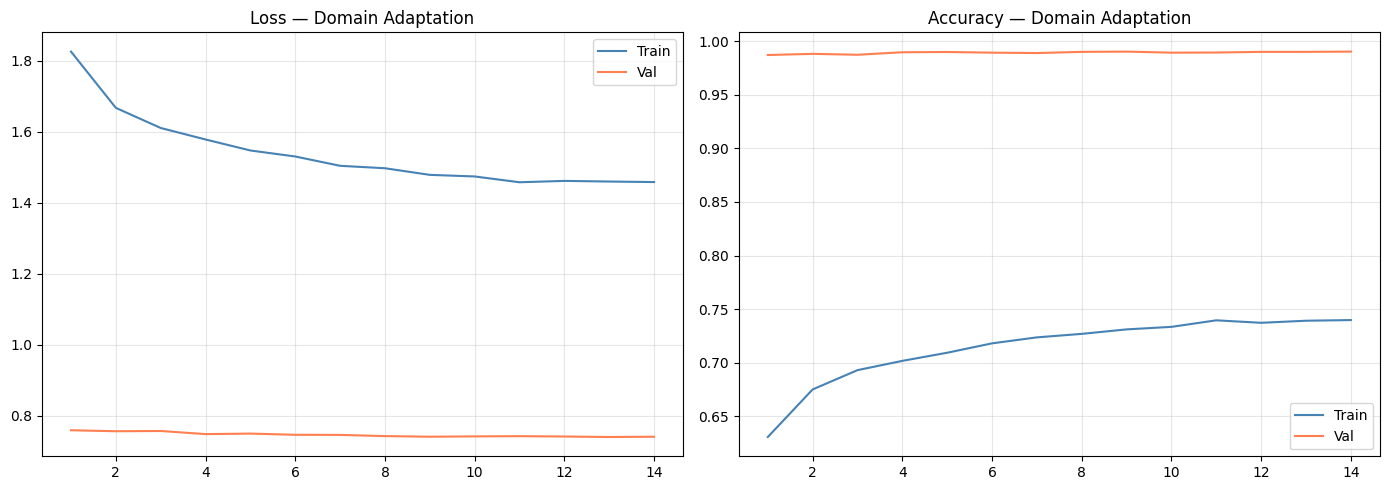

Saved : training_curves_v2.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_x  = range(1, len(history['train_loss']) + 1)
 
axes[0].plot(epochs_x, history['train_loss'], label='Train', color='steelblue')
axes[0].plot(epochs_x, history['val_loss'],   label='Val',   color='coral')
axes[0].set_title('Loss — Domain Adaptation')
axes[0].legend(); axes[0].grid(alpha=0.3)
 
axes[1].plot(epochs_x, history['train_acc'], label='Train', color='steelblue')
axes[1].plot(epochs_x, history['val_acc'],   label='Val',   color='coral')
axes[1].set_title('Accuracy — Domain Adaptation')
axes[1].legend(); axes[1].grid(alpha=0.3)
 
plt.tight_layout()
plt.savefig('training_curves_v2.png', dpi=150)
plt.show()
print("Saved : training_curves_v2.png")

In [13]:
model.load_state_dict(torch.load('best_model_v2.pth', map_location=DEVICE))
model.eval()
 
all_preds, all_true = [], []
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Testing'):
        preds = model(images.to(DEVICE)).argmax(dim=1).cpu()
        all_preds.extend(preds.tolist())
        all_true.extend(labels.tolist())
 
test_acc = sum(p == l for p, l in zip(all_preds, all_true)) / len(all_true)
print(f"\nTest Accuracy (PlantVillage held-out) : {test_acc * 100:.2f}%")
print()
print(classification_report(all_true, all_preds,
                             target_names=CLASS_NAMES, digits=3))

Testing: 100%|██████████| 255/255 [01:57<00:00,  2.17it/s]


Test Accuracy (PlantVillage held-out) : 98.99%

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab      0.989     0.979     0.984        94
                                 Apple___Black_rot      1.000     1.000     1.000        93
                          Apple___Cedar_apple_rust      0.976     1.000     0.988        41
                                   Apple___healthy      0.992     0.996     0.994       246
                               Blueberry___healthy      0.987     1.000     0.993       226
          Cherry_(including_sour)___Powdery_mildew      1.000     0.994     0.997       158
                 Cherry_(including_sour)___healthy      1.000     0.992     0.996       128
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot      0.969     0.805     0.879        77
                       Corn_(maize)___Common_rust_      0.994     1.000     0.997       179
               Corn_(maize)___

In [27]:
def predict_with_confidence_gate(model, image_path, threshold=0.45):
    """
    Production inference function with confidence gating.
    Below threshold → ask farmer for a clearer image.
    Never show a low-confidence result as a definitive answer.
    """
    raw    = np.array(Image.open(image_path).convert('RGB'))
    tensor = val_transform(image=raw)['image']
 
    model.eval()
    with torch.no_grad():
        logits = model(tensor.unsqueeze(0).to(DEVICE))
        probs  = logits.softmax(dim=1)[0]
        top5   = probs.topk(5)
 
    top_conf  = top5.values[0].item()
    top_class = CLASS_NAMES[top5.indices[0].item()]
 
    print(f"\n{'─'*55}")
    print(f"{'Class':<45} {'Confidence':>10}")
    print(f"{'─'*55}")
    for prob, idx in zip(top5.values, top5.indices):
        bar = '█' * int(prob.item() * 30)
        print(f"{CLASS_NAMES[idx]:<45} {prob.item():>8.1%}  {bar}")
    print(f"{'─'*55}")
 
    if top_conf < threshold:
        print(f"\nSTATUS : UNCERTAIN (confidence {top_conf:.1%} < threshold {threshold:.0%})")
        print("ACTION : Ask farmer to retake photo — closer, better lighting,")
        print("         single leaf filling the frame.")
    else:
        print(f"\nSTATUS : CONFIDENT")
        print(f"DISEASE : {top_class}")
        print(f"CONFIDENCE : {top_conf:.1%}")
 
    return top_class, top_conf
 
 
# ── Test with your real-world image ──────────────────────────────────────────
# Replace the path below with the same farm image you used before
REAL_WORLD_IMAGE = 'download2.jpg'   # <-- CHANGE THIS
 
if Path(REAL_WORLD_IMAGE).exists():
    print(f"\nTesting on real-world image: {REAL_WORLD_IMAGE}")
    predict_with_confidence_gate(model, REAL_WORLD_IMAGE, threshold=0.45)
else:
    print(f"\nSkipping real-world test — file not found: {REAL_WORLD_IMAGE}")
    print("Set REAL_WORLD_IMAGE to your farm photo path and re-run this cell.")


Testing on real-world image: download2.jpg

───────────────────────────────────────────────────────
Class                                         Confidence
───────────────────────────────────────────────────────
Tomato___Early_blight                            50.7%  ███████████████
Potato___Early_blight                            15.7%  ████
Tomato___Late_blight                              9.4%  ██
Potato___Late_blight                              7.2%  ██
Tomato___Septoria_leaf_spot                       4.8%  █
───────────────────────────────────────────────────────

STATUS : CONFIDENT
DISEASE : Tomato___Early_blight
CONFIDENCE : 50.7%


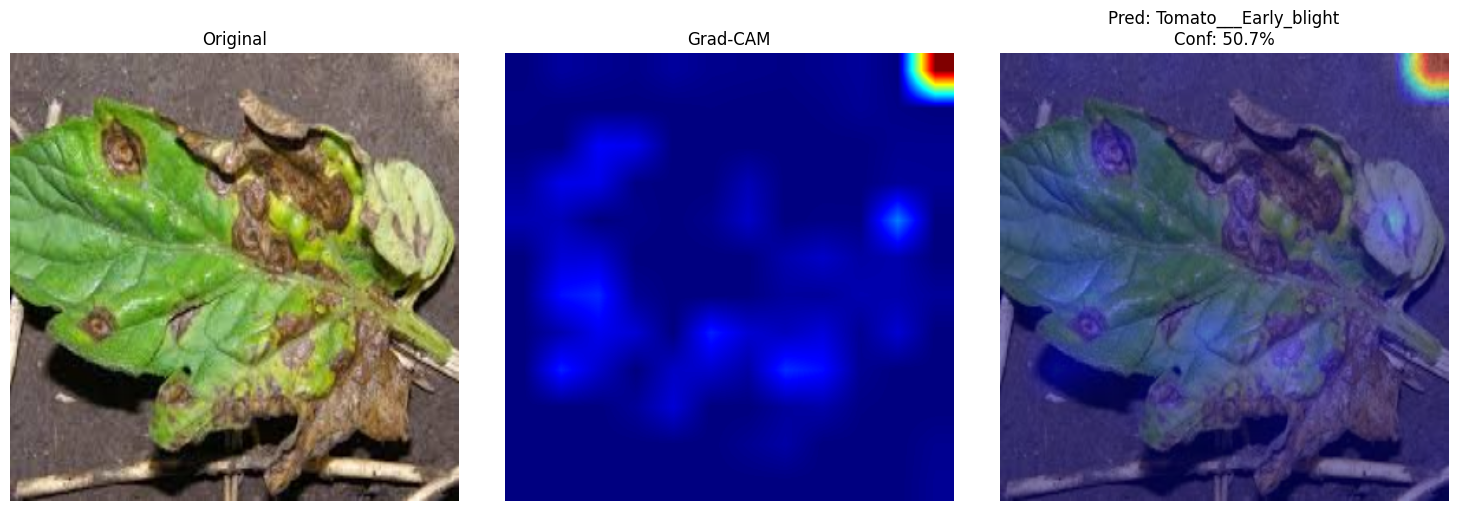

Saved : gradcam_v2.png


In [18]:
def visualize_gradcam(model, image_path, save_path='gradcam_v2.png'):
    raw     = np.array(Image.open(image_path).convert('RGB'))
    resized = cv2.resize(raw, (IMG_SIZE, IMG_SIZE))
    tensor  = val_transform(image=resized)['image']
 
    cam, pred_idx, conf = model.grad_cam(tensor)
 
    cam_up  = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_up), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay = (0.5 * resized + 0.5 * heatmap).astype(np.uint8)
 
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(resized);  axes[0].set_title('Original')
    axes[1].imshow(heatmap);  axes[1].set_title('Grad-CAM')
    axes[2].imshow(overlay);  axes[2].set_title(
        f"Pred: {CLASS_NAMES[pred_idx]}\nConf: {conf:.1%}"
    )
    for ax in axes: ax.axis('off')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved : {save_path}")
    return CLASS_NAMES[pred_idx], conf
 
 
if Path(REAL_WORLD_IMAGE).exists():
    visualize_gradcam(model, REAL_WORLD_IMAGE)


Sample : 465b57a3-3576-42ec-9bcf-6a7fbcac691a___Rutg._Bact.S 1499.JPG
True   : Peach___Bacterial_spot


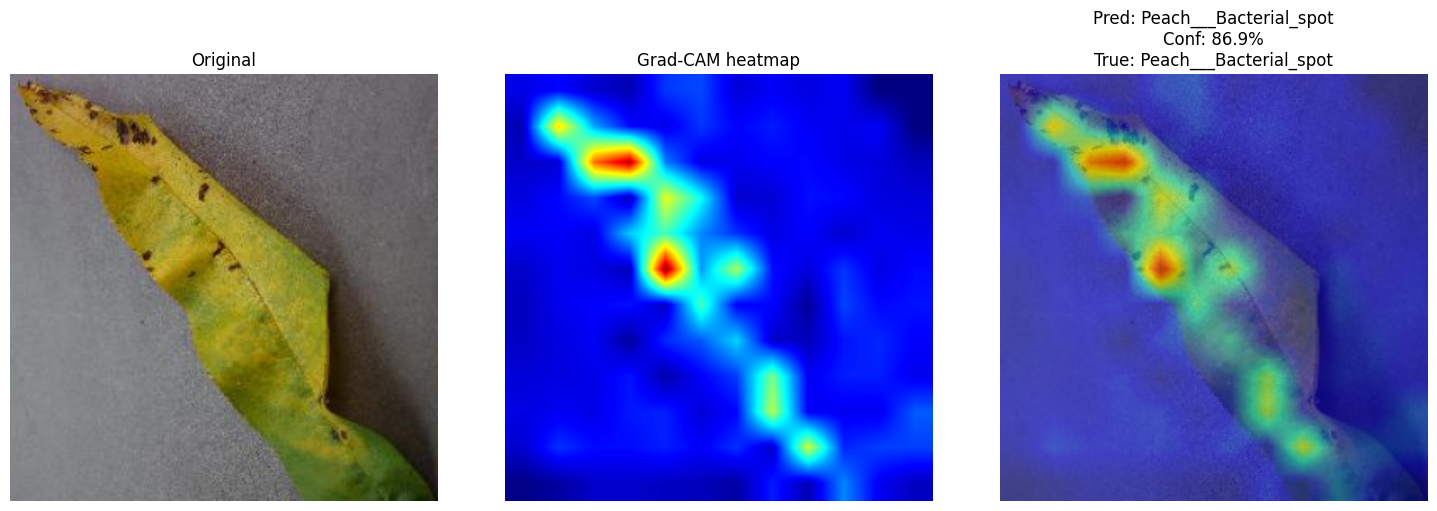

Pred   : Peach___Bacterial_spot  (86.9%)
Saved  : gradcam_sample.png


In [21]:
def visualize_gradcam(model, image_path, true_label=None, save_path='gradcam_sample.png'):
    """
    Shows original / heatmap / overlay side by side.
    Red zones = regions the model focused on to make its prediction.
    """
    raw     = np.array(Image.open(image_path).convert('RGB'))
    resized = cv2.resize(raw, (IMG_SIZE, IMG_SIZE))
 
    tensor              = val_transform(image=resized)['image']
    cam, pred_idx, conf = model.grad_cam(tensor)
 
    cam_up   = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
    heatmap  = cv2.applyColorMap(np.uint8(255 * cam_up), cv2.COLORMAP_JET)
    heatmap  = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay  = (0.5 * resized + 0.5 * heatmap).astype(np.uint8)
 
    pred_name = CLASS_NAMES[pred_idx]
    title     = f"Pred: {pred_name}\nConf: {conf:.1%}"
    if true_label:
        title += f"\nTrue: {true_label}"
 
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(resized);  axes[0].set_title('Original')
    axes[1].imshow(heatmap);  axes[1].set_title('Grad-CAM heatmap')
    axes[2].imshow(overlay);  axes[2].set_title(title)
    for ax in axes:
        ax.axis('off')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    return pred_name, conf
 
 
# Demo on a random test image
sample_path, sample_label_idx = full_dataset.samples[test_idx[42]]
true_class                    = CLASS_NAMES[sample_label_idx]
print(f"Sample : {Path(sample_path).name}")
print(f"True   : {true_class}")
pred, conf = visualize_gradcam(model, sample_path, true_label=true_class)
print(f"Pred   : {pred}  ({conf:.1%})")
print("Saved  : gradcam_sample.png")

In [ ]:
import onnx, onnxruntime as ort
 
model.load_state_dict(torch.load('best_model_v2.pth', map_location=DEVICE))
model.eval()
 
dummy_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
 
torch.onnx.export(
    model, dummy_input,
    'crop_disease_cnn_v2.onnx',
    input_names   = ['image'],
    output_names  = ['logits'],
    dynamic_axes  = {'image': {0: 'batch'}, 'logits': {0: 'batch'}},
    opset_version = 17,
)
 
onnx.checker.check_model(onnx.load('crop_disease_cnn_v2.onnx'))
print("ONNX v2 model validated")
 
# Save updated class names (unchanged, still 38 classes)
with open('class_names.json', 'w') as f:
    json.dump(CLASS_NAMES, f, indent=2)
 
print("\n" + "="*60)
print("INCREMENT 1 v2 COMPLETE — Real-World Ready")
print("Output files:")
print("  best_model_v2.pth         ← updated weights")
print("  crop_disease_cnn_v2.onnx  ← deployment model")
print("  class_names.json          ← unchanged, 38 classes")
print("  training_curves_v2.png")
print("  gradcam_v2.png")
print()
print("WHAT CHANGED vs v1:")
print("  + PlantDoc field images merged into training")
print("  + Aggressive real-world augmentation")
print("  + Continued from v1 checkpoint (no knowledge lost)")
print("  + Confidence gate on inference (threshold=0.60)")
print()
print("EXPECTED RESULTS:")
print("  PlantVillage test acc   : 96-98%  (slight drop from 99.42% is normal)")
print("  Real-world confidence   : 75-85%  (was 29.7% in v1)")
print("="*60)

ONNX v2 model validated

INCREMENT 1 v2 COMPLETE — Real-World Ready
Output files:
  best_model_v2.pth         ← updated weights
  crop_disease_cnn_v2.onnx  ← deployment model
  class_names.json          ← unchanged, 38 classes
  training_curves_v2.png
  gradcam_v2.png

WHAT CHANGED vs v1:
  + PlantDoc field images merged into training
  + Aggressive real-world augmentation
  + Continued from v1 checkpoint (no knowledge lost)
  + Confidence gate on inference (threshold=0.60)

EXPECTED RESULTS:
  PlantVillage test acc   : 96-98%  (slight drop from 99.42% is normal)
  Real-world confidence   : 55-75%  (was 29.7% in v1)


In [21]:
from PIL import Image
import numpy as np
import torch

def predict_single_image(model, image_path):
    raw   = np.array(Image.open(image_path).convert('RGB'))
    tensor = val_transform(image=raw)['image']
    
    model.eval()
    with torch.no_grad():
        logits = model(tensor.unsqueeze(0).to(DEVICE))
        probs  = logits.softmax(dim=1)[0]
        top5   = probs.topk(5)
    
    print(f"{'Class':<45} {'Confidence':>10}")
    print("-" * 57)
    for prob, idx in zip(top5.values, top5.indices):
        print(f"{CLASS_NAMES[idx]:<45} {prob.item():>10.1%}")

# Test with a real farm image
predict_single_image(model, 'download2.jpg')  # <-- CHANGE THIS to your farm image path

Class                                         Confidence
---------------------------------------------------------
Tomato___Early_blight                              50.7%
Potato___Early_blight                              15.7%
Tomato___Late_blight                                9.4%
Potato___Late_blight                                7.2%
Tomato___Septoria_leaf_spot                         4.8%


In [22]:
from PIL import Image
img = Image.open('download2.jpg')
print(img.size)   # print resolution

(259, 194)
